In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

In [5]:
datasS0 = [np.load("background_data_profiles_free_case/sigma_0_Mult_%s.npy"%i, allow_pickle=True) for i in range(25)] #22

In [6]:
datasS0[7][0][2][0]

0.86

In [6]:
# datasS0[16][0][2][0], datasS0[16][1][2][0], datasS0[16][1][3][0]

#### Phase plot

In [6]:
import matplotlib as mpl
import Modules.EnergyMass as en


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap

In [7]:
# Checking that all configurations have the same mass up to the first decimal point.
LambT, gamma = 0, 0
datosTemp = []
datosMasa = []
print('#'*10)
for s0 in datasS0:
    MT, EnT = 0, 0
    pdata, temp = [], []
    for data in s0:
        Ei, rad, sDnew, dsDnew, uDnew, duDnew = data
        print(sDnew[0])
        Masa = en.massVal(rad, sDnew**2)
        arg2 = [LambT, gamma]  # Calculando la masa de la componente
        Enf, _, _ = en.EnFuncion([rad, sDnew, None], arg2)  # Calculando la energía de la componente
    
        MT += Masa  # Calculando la masa total
        EnT += Enf  # Calculando la energía total
        
        temp.append(Masa)
        pdata.append(sDnew[0])
        
    print('Masa = %4.1f'%MT)
    datosTemp.append(np.concatenate(([MT, EnT], pdata)))  # Guardando los datos
    datosMasa.append(temp)
print('#'*10)

datosSig0EnMas = []
datosSig0EnMas.append(np.array(datosTemp))  # Convierte y almacena los datos

##########
1.0
0.0
0.0
Masa = 43.6
0.99
0.025
0.0
Masa = 43.4
0.987
0.05
0.0
Masa = 43.5
0.975
0.075
0.0
Masa = 43.5
0.96
0.1


/Users/armandoroqueestrada/Proyecto_Proca/Stability/Modules/EnergyMass/energy_mass.py:134: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Tval = 4 * np.pi * quad(intf, rmin, rfin)[0]


0.0
Masa = 43.6
0.93
0.125
0.0
Masa = 43.5
0.9
0.15
0.0
Masa = 43.5
0.86
0.175
0.0
Masa = 43.5
0.81
0.2


/Users/armandoroqueestrada/Proyecto_Proca/Stability/Modules/EnergyMass/energy_mass.py:134: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  Tval = 4 * np.pi * quad(intf, rmin, rfin)[0]


0.0
Masa = 43.6
0.74
0.225
0.0
Masa = 43.5
0.64
0.25
0.0
Masa = 43.6
0.57
0.26
0.0
Masa = 43.6
0.51
0.265
0.0
Masa = 43.6
0.46
0.267
0.0
Masa = 43.6
0.39
0.265
0.0
Masa = 43.5
0.32
0.26
0.0
Masa = 43.5
0.29
0.258
0.0
Masa = 43.6
0.27
0.255
0.0
Masa = 43.6
0.26
0.2525
0.0
Masa = 43.5
0.24
0.25
0.0
Masa = 43.6
0.19
0.24
0.0
Masa = 43.5
0.145
0.23
0.0
Masa = 43.6
0.105
0.22
0.0
Masa = 43.6
0.065
0.21
0.0
Masa = 43.5
0.0
0.202
0.0
Masa = 43.6
##########


In [9]:
# datosMasa

In [10]:
# datosMasa
np.save("multif_masa_i", datosMasa)
np.save("multif_masa_En_pi", datosTemp)

In [11]:
#datosSig0EnMas

In [8]:
# creando barra de colores normalizada
col = ['#1a1919', '#f0784d', '#2681ab', '#ab262f', '#bc92e0', '#486318', '#ed5b0c', 
      '#f0a092', '#484f07', '#694d0c']

# normalizando con el de maximo y mínimo global energía
maxD = [np.max(data[:, 1]) for data in datosSig0EnMas]
minD = [np.min(data[:, 1]) for data in datosSig0EnMas]

maximo = max(maxD)
minimo = min(minD)

print(minimo, maximo)

# creando barra de colores normalizada
cmap = LinearSegmentedColormap.from_list('', 
                                        [(0, '#c23838'),
                                         (0.25, '#f0784d'),  # (0.25, '#f0784d')
                                         (0.5, '#337512'),
                                         (0.75, '#1dc4ab'),
                                         (1, '#2681ab')], N=2000)

#cmap = LinearSegmentedColormap.from_list('', ['#f0784d', '#2681ab'])  # 
norm =  mpl.colors.Normalize(vmin=minimo, vmax=maximo)  # mpl.colors.PowerNorm(gamma=1.9, vmin=minimo, vmax=maximo)  #
sm = ScalarMappable(norm=norm, cmap=cmap)

-33293.730149775445 -1.7207504133558682


(-0.02, 1.02)

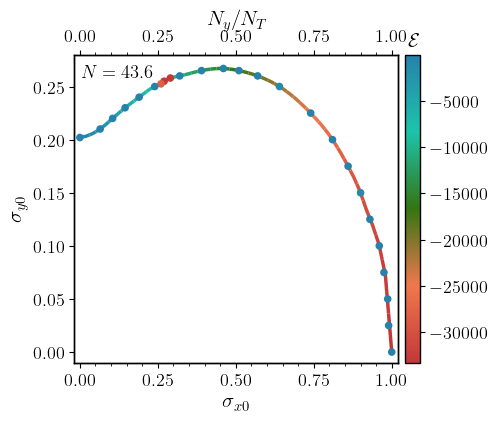

In [13]:
# Plot

## creando la figura
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4.5, 4))

for data in datosSig0EnMas: 
    # Data
    mass = data[0, 0]  # it is the same for all configuations
    Et = data[:, 1]
    sigx = data[:, 2]
    sigy = data[:, 3]

    # interpolando la curva
    fun = interp1d(sigx, sigy, kind="quadratic")
    sval = np.linspace(sigx[0], sigx[-1], 50)  # creando datos a evaluar
    
    color = np.linspace(0, 2, sval.size)
    lines = cplot.colored_line(sval, fun(sval), color, ax, linewidth=2.5, cmap=cmap)  # graficando la linea con gradiente de color

    #ax.scatter(sigx[1:-1], sigy[1:-1], c=Et[1:-1], vmin=min(Et[1:-1]), vmax=max(Et[1:-1]), s=25, cmap=cmap, zorder=100)  # graficando los puntos
    ax.scatter(sigx[:], sigy[:], c=Et[:], norm=norm, s=20, cmap=cmap, zorder=100)  # graficando los puntos


    # graficando las configuraciones final e inicial
    #ax.plot(sigx[-1], sigy[-1], ls='', marker='*', markersize=8, c='#2681ab', label=r'stationary (linear) $1$st-excited state')
    #ax.plot(sigx[0], sigy[0], ls='', marker='*', markersize=8, c='#f0784d', label=r'stationary (linear) ground state')

# texto
ax.text(x=0.005, y=0.259, s=r'$N=%3.1f$'%mass, fontsize='small')

# Limites/labels
ax.set_xlabel(r'$\sigma_{x 0}$')
ax.set_ylabel(r'$\sigma_{y 0}$')
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.01, 0.28)

# Poniendo la barra de color
cbar = fig.colorbar(sm, fraction=0.05, pad=0.02, ax=ax, aspect=20, location='right')
cbar.ax.set_title(r'$\mathcal{E}$', fontsize=14)
#cbar.ax.plot(0.5, min(Et), 'w.')

# Legenda
# ax.legend(loc=(0, 0.02), frameon=False, fontsize=12.5, handletextpad=0.3) # , title=r'$n_x=0, n_y=1, n_z=0$'

ax0 = ax.twiny()

totalM = np.sum(datosMasa, axis=1)
for j in range(22):
    #print(j,  '->', (datosMasa[j][1]/totalM[j]))
    ax0.plot(sigx[j], sigy[j], ls='')
ax0.set_xlabel(r'$N_y/N_T$')
ax0.set_xlim([-0.02, 1.02])    
ax.set_xlim([-0.02, 1.02])


In [14]:
(datosMasa[12][1]/totalM[12]), (datosMasa[9][1]/totalM[9])

(0.3596910580721546, 0.17221934658635038)

### Stability 

In [9]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [16]:
# datasS0

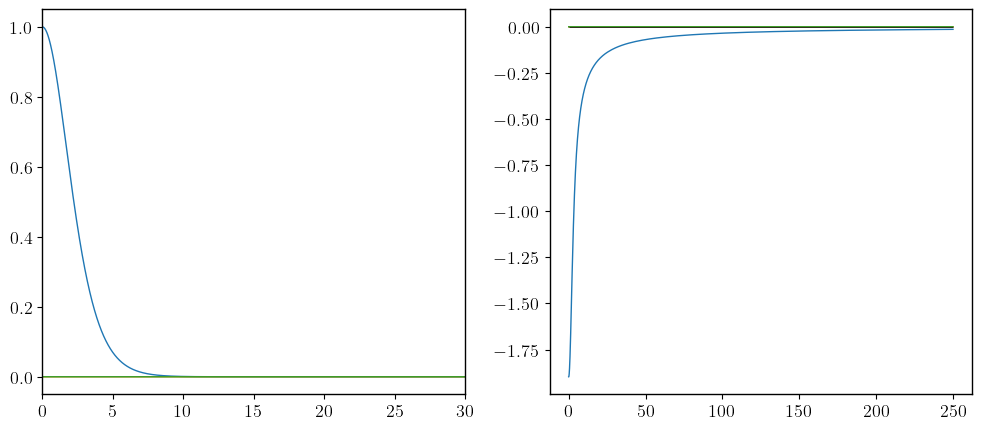

In [10]:
# perf 0
# Debo recuperar los resultados de la polarización linal con n=0

datE = []
datFunc = [[], []]
for s0dat in datasS0[0]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 0
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [11]:
for ind, [Jval, data] in enumerate(dataExtra):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

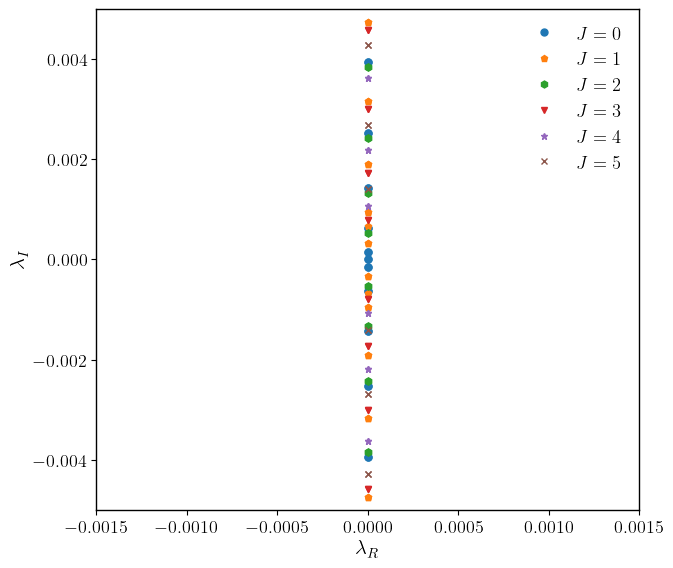

In [12]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtra):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
ax.set_xlim(-0.0015, 0.0015)
ax.set_ylim(-.005, .005)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [20]:
# este modo desaparece y notar como es el modo trivial

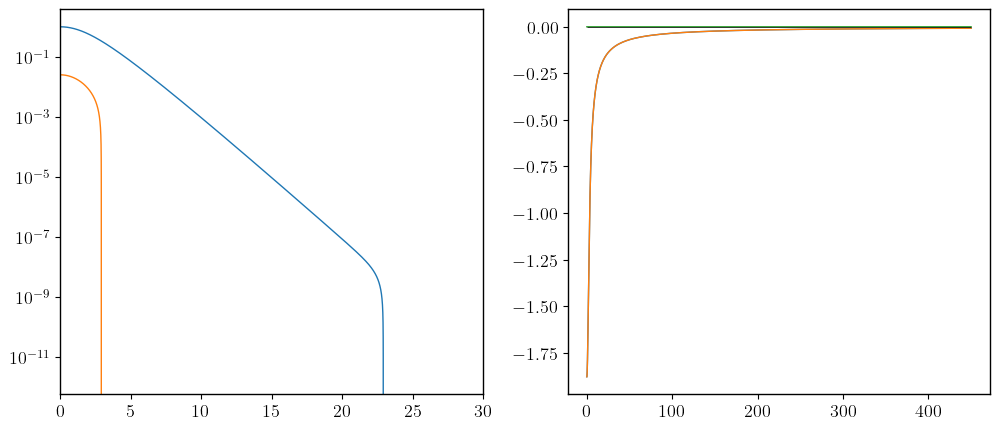

In [13]:
# perf 1

datE = []
datFunc = [[], []]
for s0dat in datasS0[1]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn1, dataExtran1 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [14]:
for ind, [Jval, data] in enumerate(dataExtran1):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

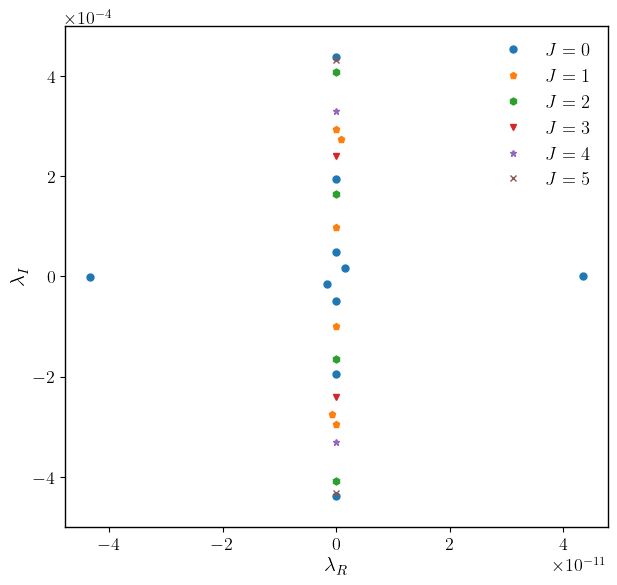

In [15]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran1):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.0015, 0.0015)
ax.set_ylim(-.0005, .0005)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [24]:
# perf 2

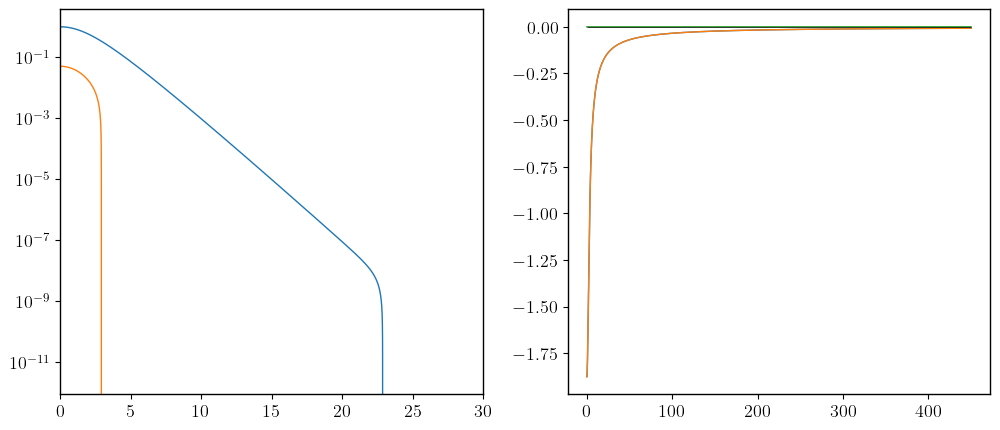

In [16]:
datE = []
datFunc = [[], []]
for s0dat in datasS0[2]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn2, dataExtran2 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [17]:
for ind, [Jval, data] in enumerate(dataExtran2):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

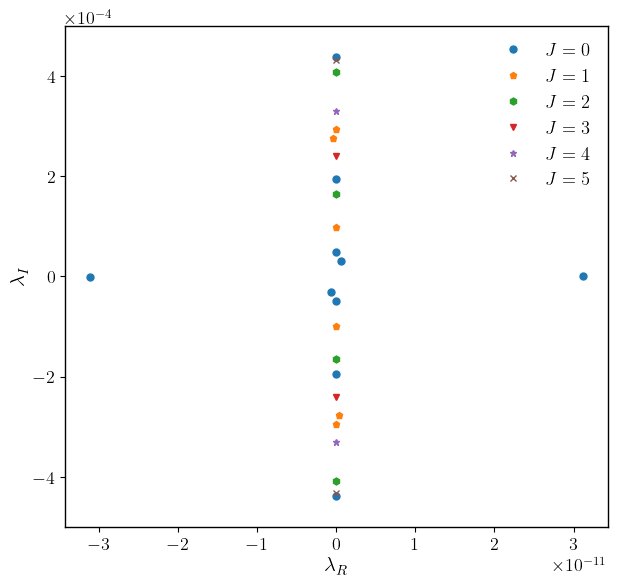

In [18]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran2):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.0015, 0.0015)
ax.set_ylim(-.0005, .0005)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [28]:
# perf 3

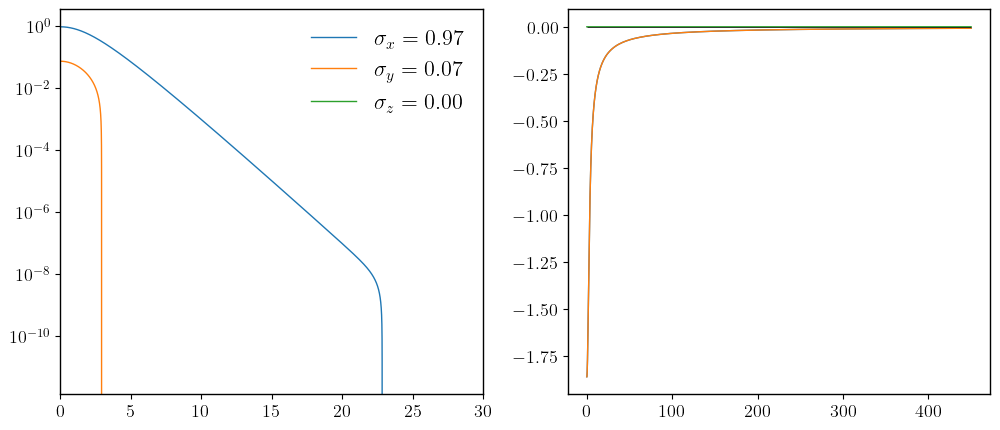

In [19]:
datE = []
datFunc = [[], []]
for s0dat in datasS0[3]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s = %3.2f$'%(label[i], datFunc[0][i](0)), lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
ax[0].legend(frameon=False)
plt.show()

lambdaValn3, dataExtran3 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [20]:
for ind, [Jval, data] in enumerate(dataExtran3):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

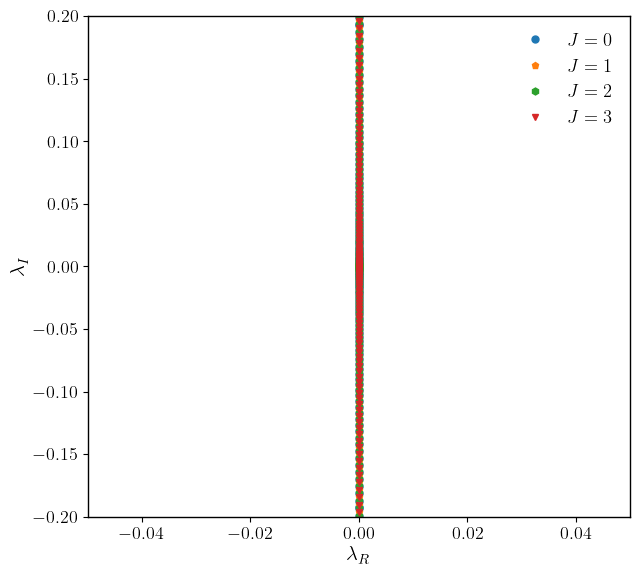

In [ ]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran3):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [32]:
# perf 4

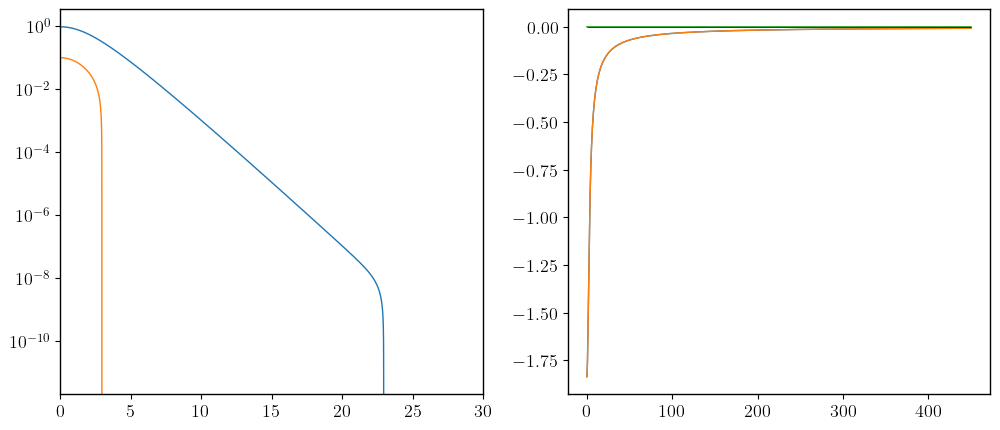

In [21]:
datE = []
datFunc = [[], []]
for s0dat in datasS0[4]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax /4 ) #* 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn4, dataExtran4 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [22]:
for ind, [Jval, data] in enumerate(dataExtran4):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

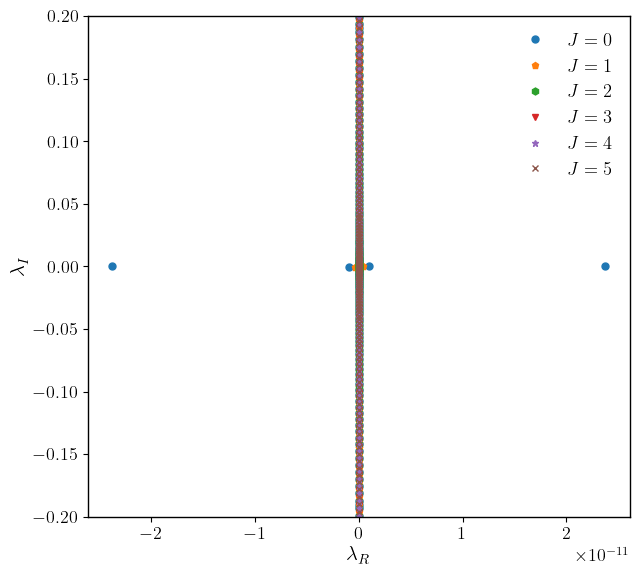

In [23]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran4):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [36]:
# perf 5

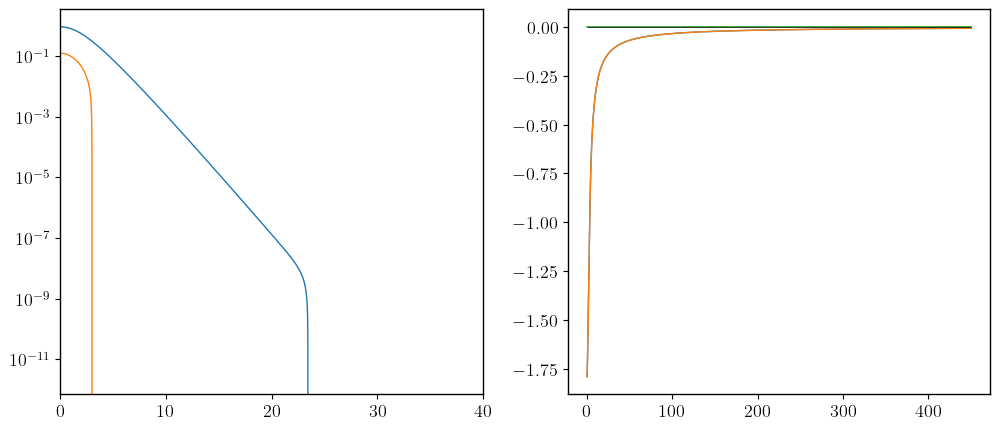

In [24]:
datE = []
datFunc = [[], []]
for s0dat in datasS0[5]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 40)
ax[0].set_yscale('log')
plt.show()

lambdaValn5, dataExtran5 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [25]:
for ind, [Jval, data] in enumerate(dataExtran5):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

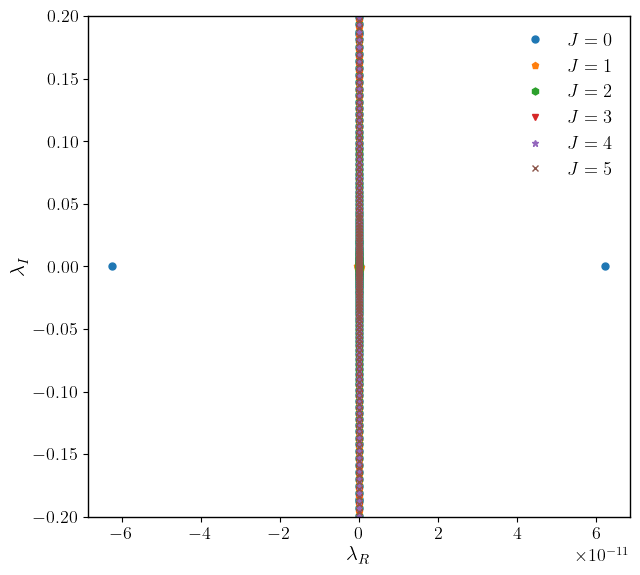

In [26]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran5):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

0.9
0.15
0.0


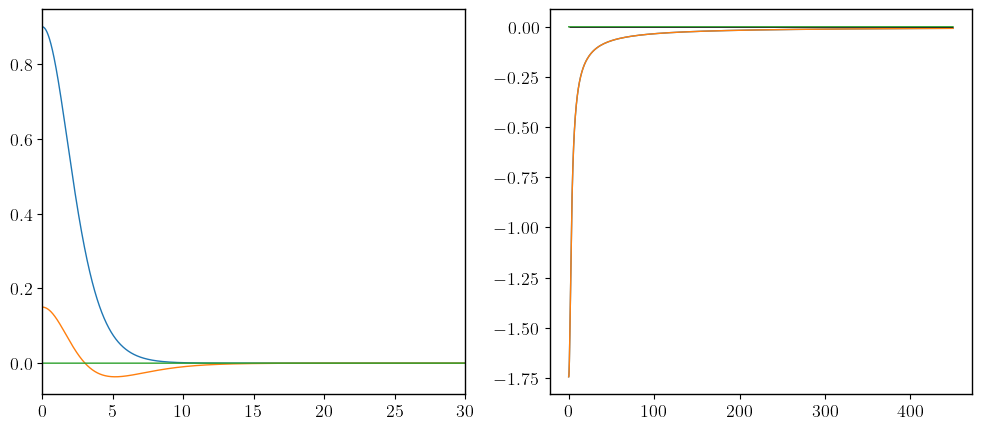

In [27]:
# perf 6

datE = []
datFunc = [[], []]
for s0dat in datasS0[6]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) #* 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    print(datFunc[0][i](0))
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaValn6, dataExtran6 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [28]:
for ind, [Jval, data] in enumerate(dataExtran6):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[ 0.00178035-0.13755685j -0.00178035-0.13755685j -0.00178035+0.13755685j
  0.00178035+0.13755685j]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

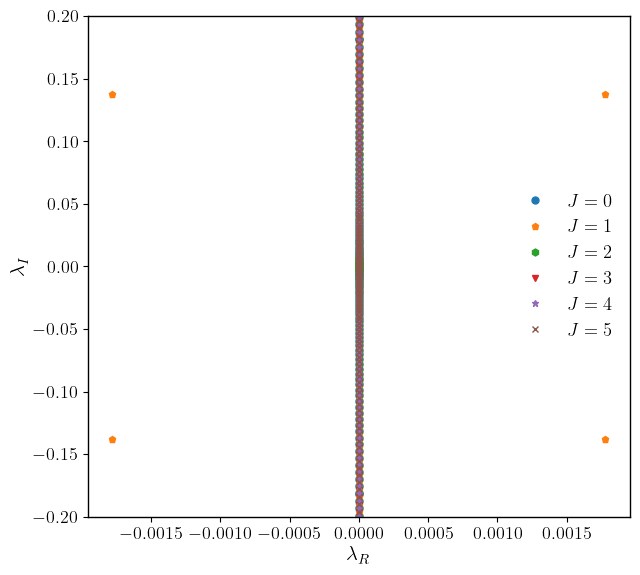

In [29]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran6):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

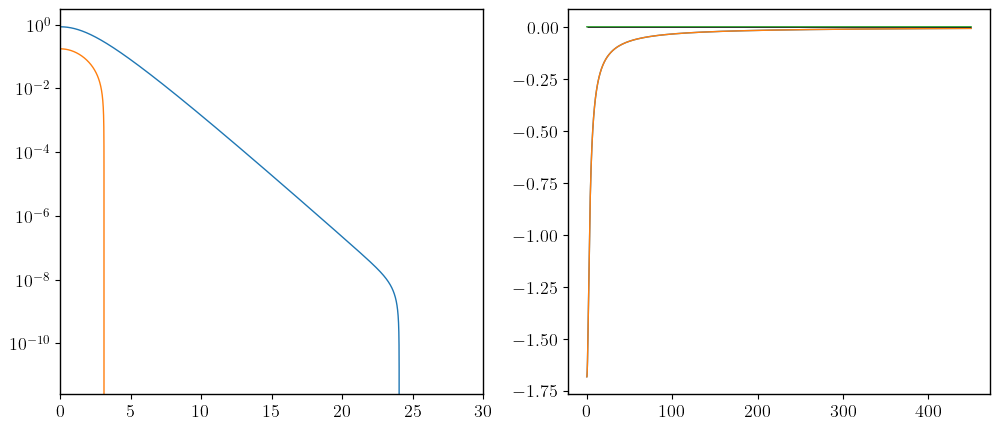

In [30]:
# perf 7

datE = []
datFunc = [[], []]
for s0dat in datasS0[7]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn7, dataExtran7 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [31]:
for ind, [Jval, data] in enumerate(dataExtran7):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-1.17580447e-07-6.42992184e-10j  1.17580455e-07+6.42834593e-10j]
Jval = 1
[-0.00253513+0.13385269j -0.00253513-0.13385269j  0.00253513-0.13385269j
  0.00253513+0.13385269j]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

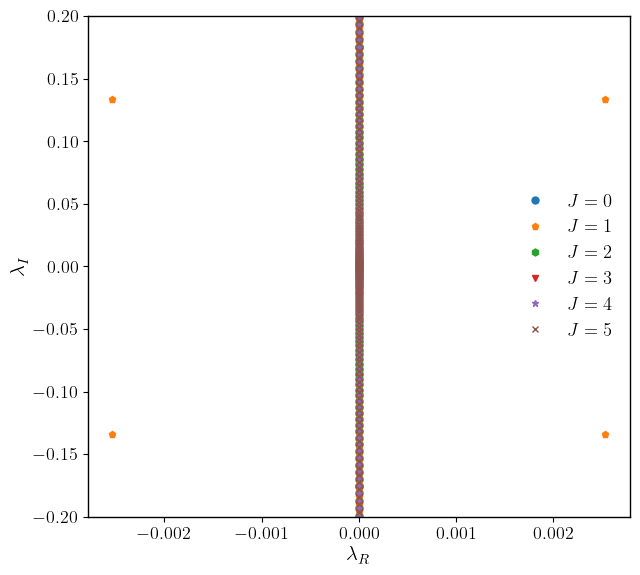

In [32]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran7):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

Jval = 0
[-1.17580447e-07-6.42992184e-10j  1.17580455e-07+6.42834593e-10j]
Jval = 1
[-0.00253513+0.13385269j -0.00253513-0.13385269j  0.00253513-0.13385269j
  0.00253513+0.13385269j]
Jval = 2
[]
Jval = 3
[]


/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_56822/3484251702.py:33: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[0][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][0])
/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_56822/3484251702.py:34: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[1][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][1])


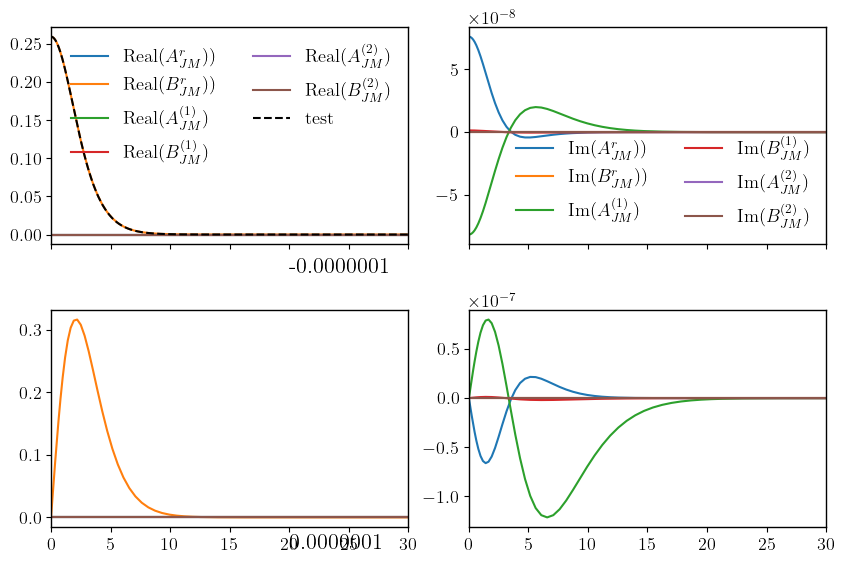

In [46]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6.5),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.3, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

# dataExtra.append([J, list([r_dis2, LambdaRealSorted, eig_vectors_sorted[:, jj]])])
for ind, [Jval, data] in enumerate(dataExtran7):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)    
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])
    
    if Jval==0:
        labels = ['$A_{JM}^{r}$)', '$B_{JM}^{r})$', '$A_{JM}^{(1)}$', '$B_{JM}^{(1)}$', '$A_{JM}^{(2)}$', '$B_{JM}^{(2)}$']
        datay = (eigVect[:, ind])[:, 0]
        for i in range(6):
            ax[0][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)])/rdis, label=r'Real(%s)'%labels[i])  # notar que /rdis
            ax[0][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)])/rdis, label=r'Im(%s)'%labels[i])
        
        i = 1
        valc = (np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)])/rdis)[0]/datFunc[0][0](0)
        ax[0][0].plot(rad, datFunc[0][0](rad)*valc, c='k', ls='--', label='test')
        # ax[0][1].plot(rad, datFunc[0][1](rad)*0.302, c='k', label='test')
        
        ax[0][0].legend(frameon=False, fontsize='small', ncol=2)
        ax[0][1].legend(frameon=False, fontsize='small', ncol=2)
        
        datay = (eigVect[:, ind])[:, 1]
        for i in range(6):
            ax[1][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[1][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])
        
        ax[0][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][0])
        ax[1][0].text(x=20, y=-0.05, s=r'%8.7f'%eingVal[ind][1])
        ax[0][0].set_xlim(0, 30)
        ax[0][1].set_xlim(0, 30)
        #ax[0][0].set_ylim(-0.002, 0.002)

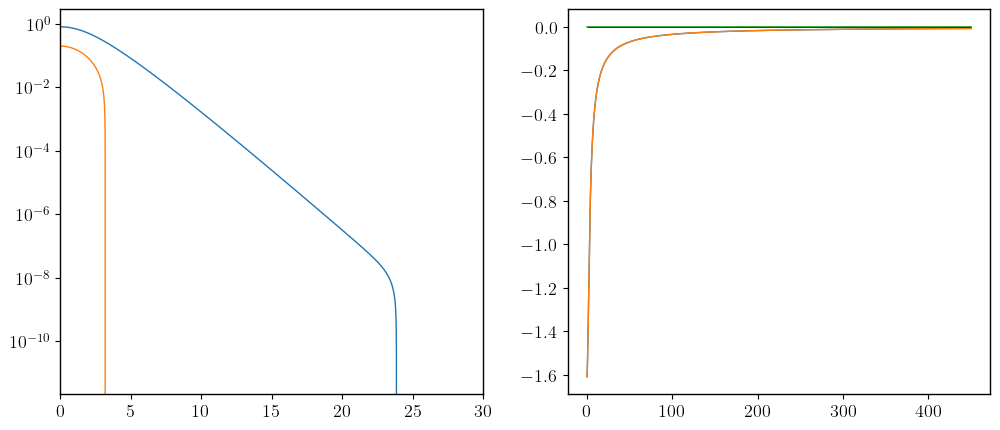

In [33]:
# perf 8

datE = []
datFunc = [[], []]
for s0dat in datasS0[8]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn8, dataExtran8 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [34]:
for ind, [Jval, data] in enumerate(dataExtran8):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[-0.00290684-0.12923513j  0.00290684-0.12923513j  0.00290684+0.12923513j
 -0.00290684+0.12923513j]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

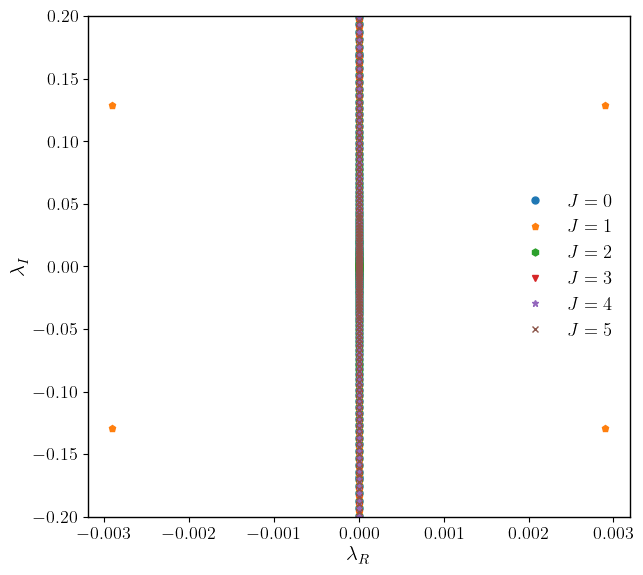

In [35]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran8):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

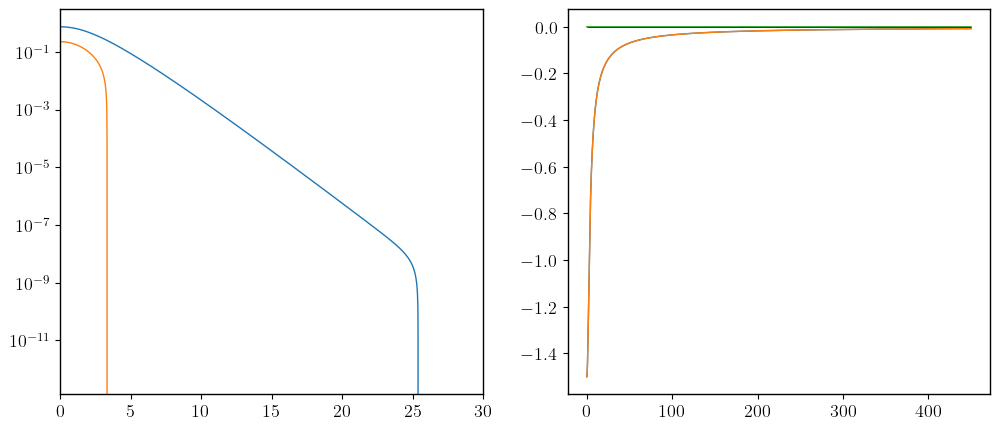

In [36]:
# perf 9

datE = []
datFunc = [[], []]
for s0dat in datasS0[9]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn9, dataExtran9 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [37]:
for ind, [Jval, data] in enumerate(dataExtran9):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-1.76057252e-07-1.39945552e-11j  1.76057252e-07+1.41693321e-11j]
Jval = 1
[-0.00274983-0.12253308j  0.00274983-0.12253308j -0.00274983+0.12253308j
  0.00274983+0.12253308j]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

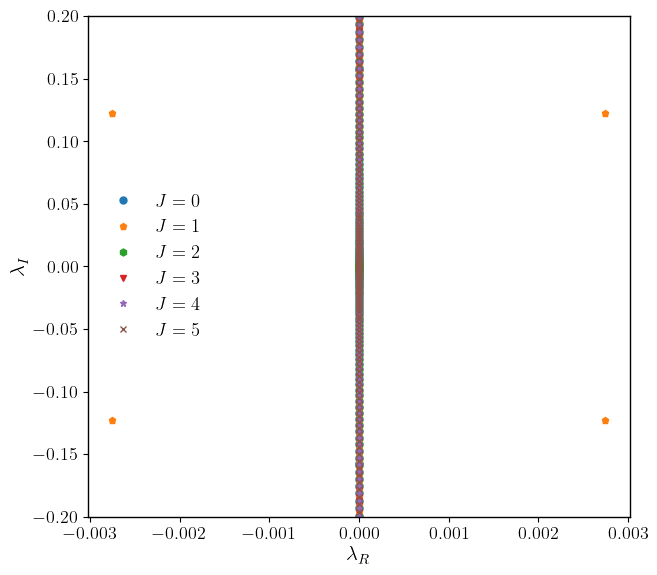

In [38]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran9):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

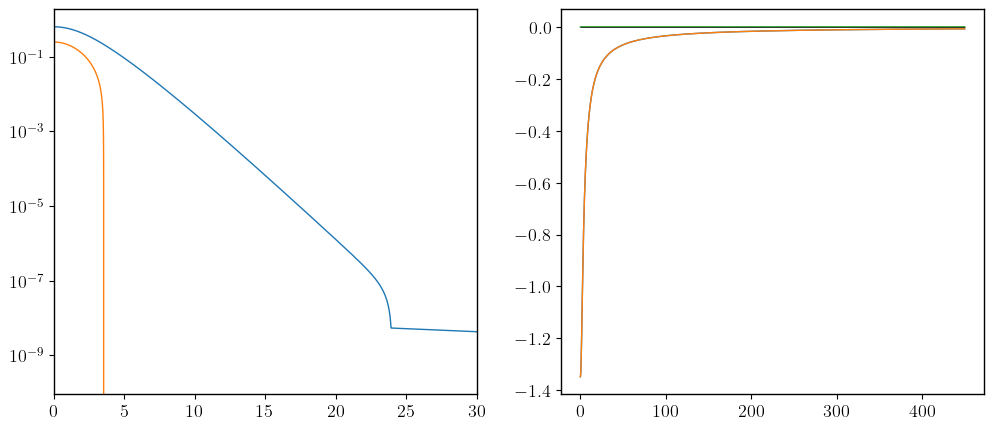

In [39]:
# perf 10

datE = []
datFunc = [[], []]
for s0dat in datasS0[10]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn10, dataExtran10 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [40]:
for ind, [Jval, data] in enumerate(dataExtran10):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

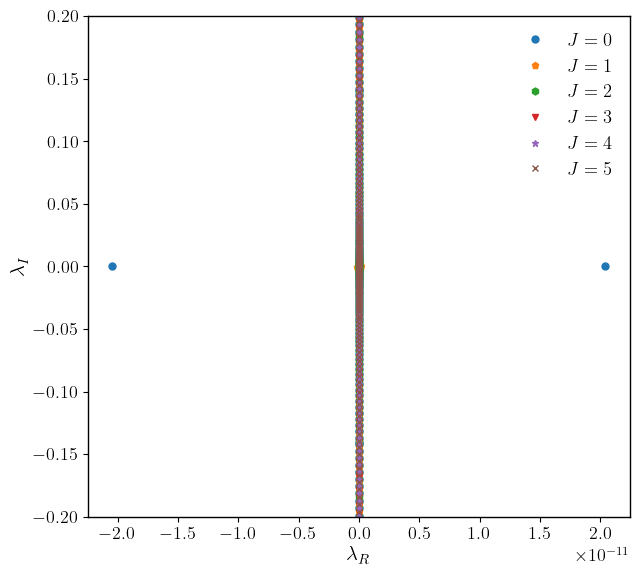

In [41]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran10):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

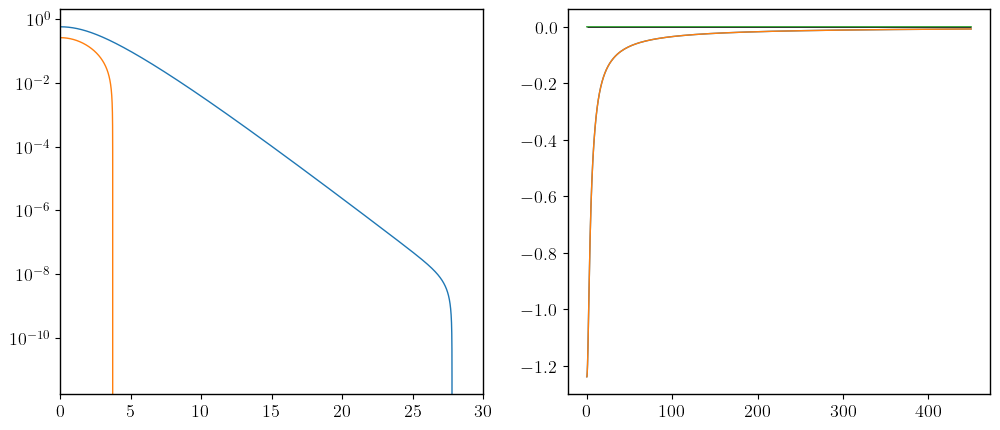

In [42]:
# perf 11

datE = []
datFunc = [[], []]
for s0dat in datasS0[11]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn11, dataExtran11 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [43]:
for ind, [Jval, data] in enumerate(dataExtran11):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

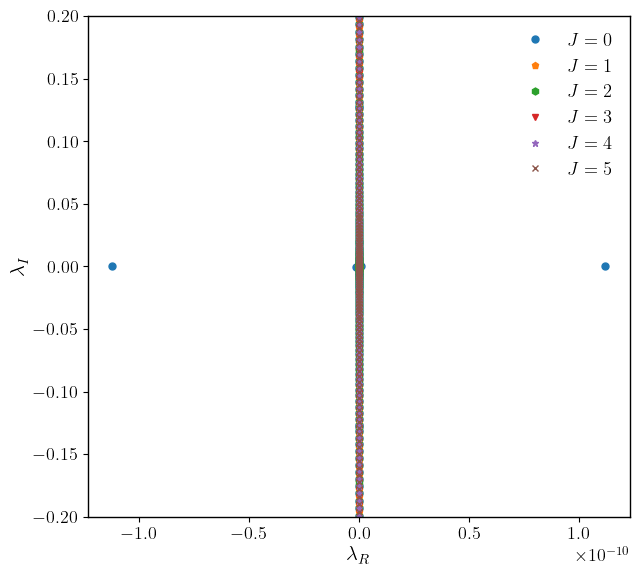

In [44]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran11):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

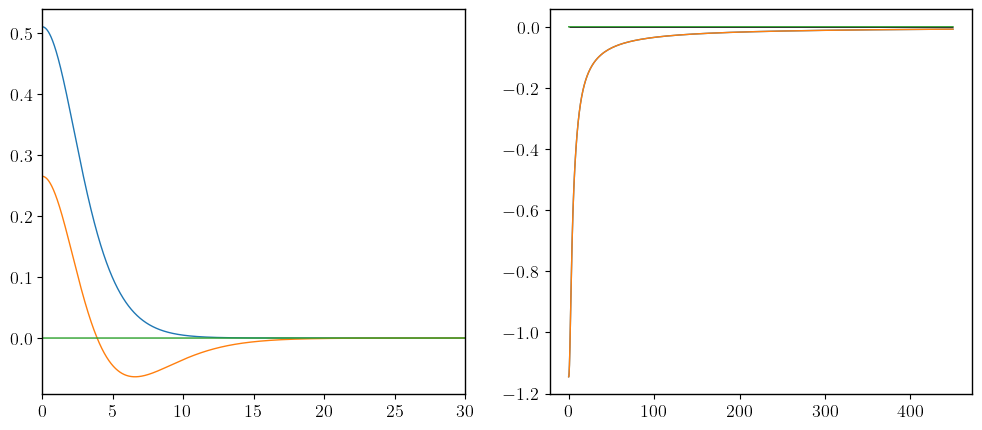

In [45]:
# perf 12

datE = []
datFunc = [[], []]
for s0dat in datasS0[12]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
#ax[0].set_yscale('log')
plt.show()

lambdaValn12, dataExtran12 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [46]:
for ind, [Jval, data] in enumerate(dataExtran12):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

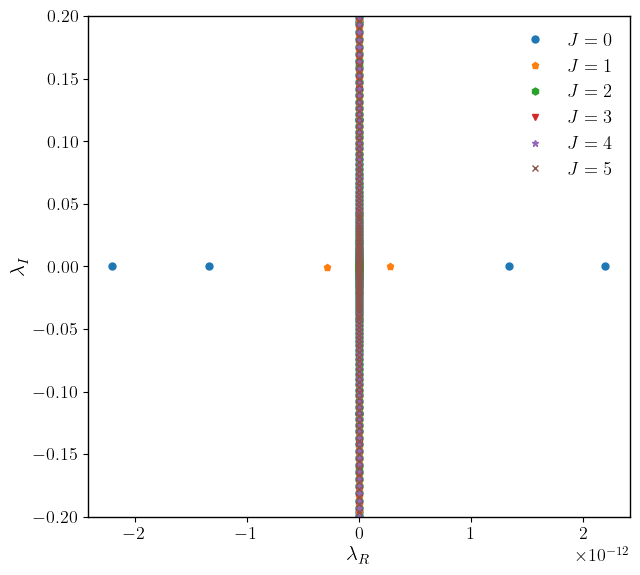

In [47]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran12):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

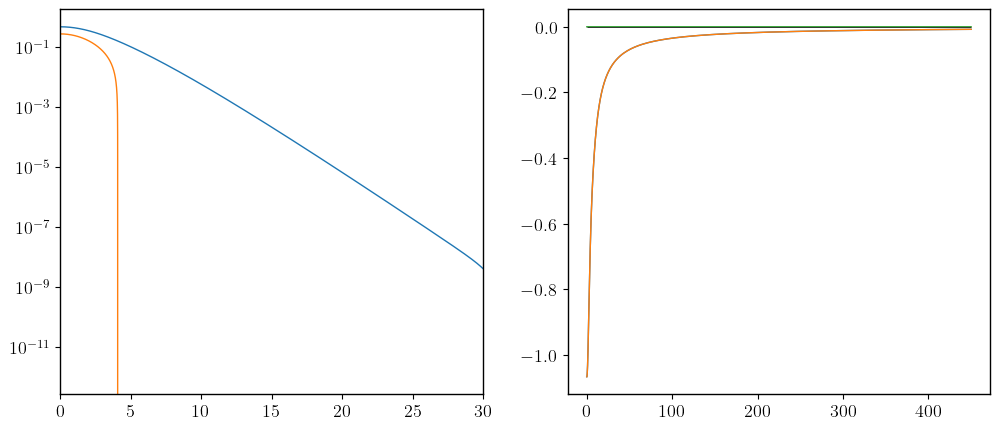

In [48]:
# perf 13

datE = []
datFunc = [[], []]
for s0dat in datasS0[13]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn13, dataExtran13 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [49]:
for ind, [Jval, data] in enumerate(dataExtran13):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

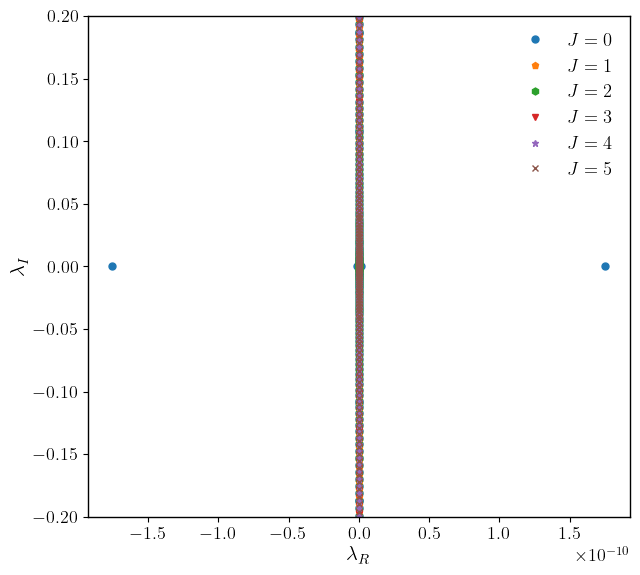

In [50]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran13):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

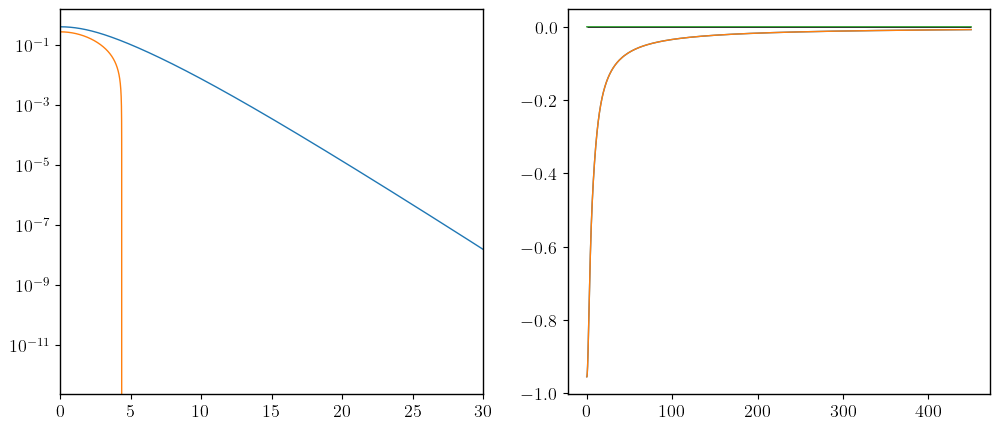

In [51]:
# perf 14

datE = []
datFunc = [[], []]
for s0dat in datasS0[14]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn14, dataExtran14 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [52]:
for ind, [Jval, data] in enumerate(dataExtran14):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

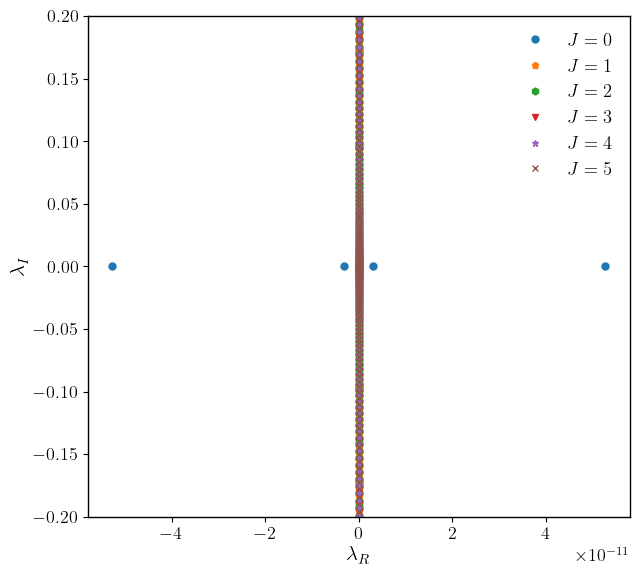

In [53]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran14):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

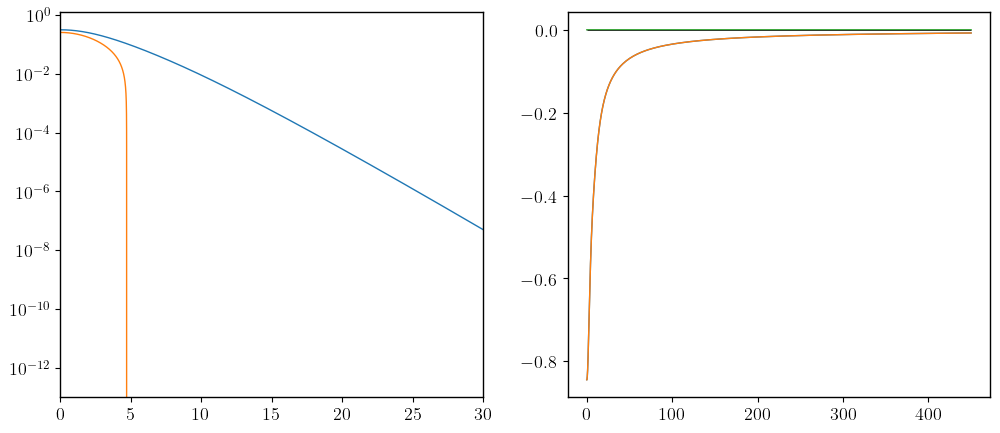

In [54]:
# perf 15

datE = []
datFunc = [[], []]
for s0dat in datasS0[15]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn15, dataExtran15 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [55]:
for ind, [Jval, data] in enumerate(dataExtran15):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00158838-0.21816049j  0.00158838-0.21816049j  0.00158838+0.21816049j
 -0.00158838+0.21816049j]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

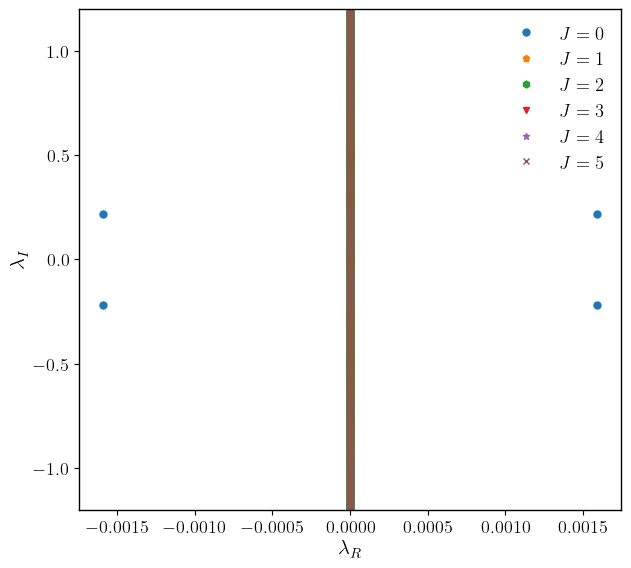

In [56]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran15):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-1.2, 1.2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

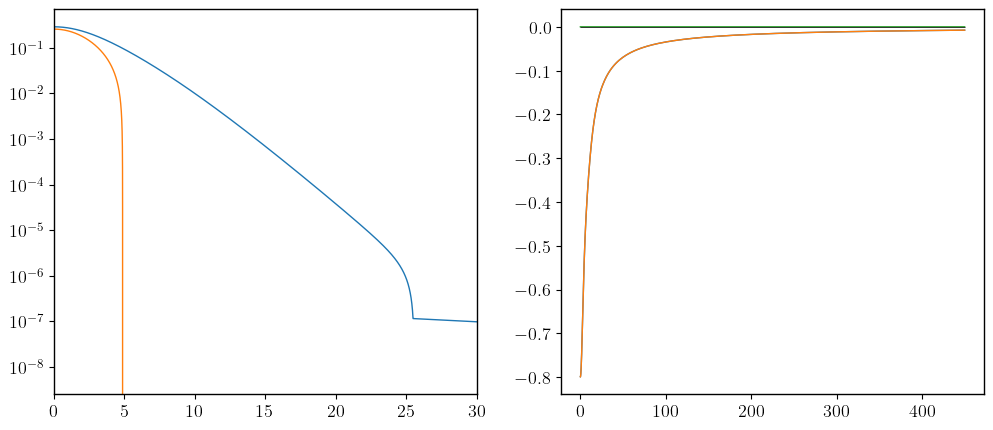

In [57]:
# perf 16

datE = []
datFunc = [[], []]
for s0dat in datasS0[16]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn16, dataExtran16 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [58]:
for ind, [Jval, data] in enumerate(dataExtran16):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00524078-0.21021668j  0.00524078-0.21021668j -0.00524078+0.21021668j
  0.00524078+0.21021668j]
Jval = 1
[]
Jval = 2
[ 0.00525841-6.36273889e-16j -0.00525841-8.54303994e-16j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

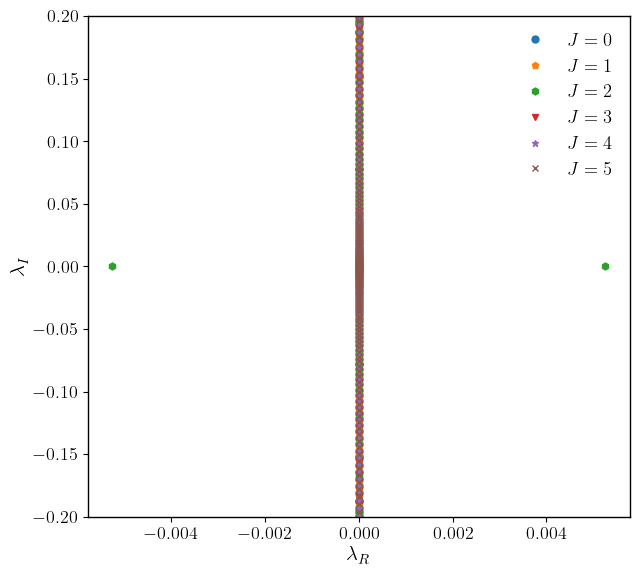

In [59]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran16):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

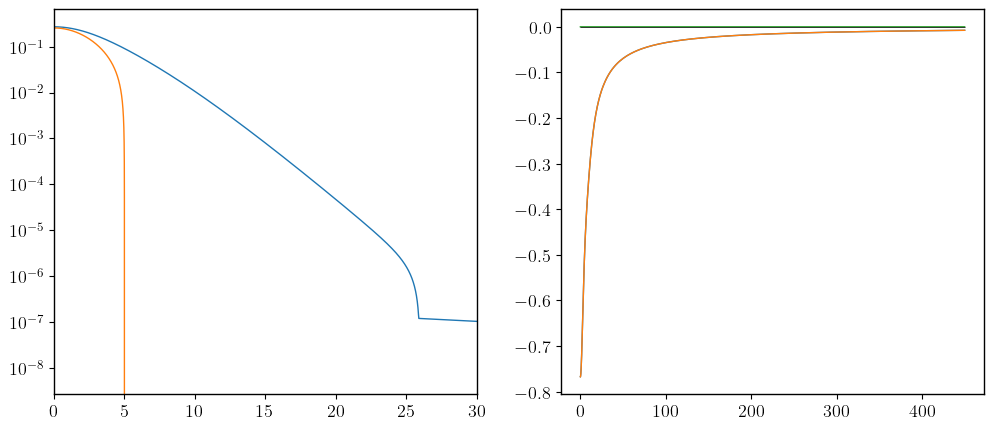

In [60]:
# perf 17

datE = []
datFunc = [[], []]
for s0dat in datasS0[17]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn17, dataExtran17 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [61]:
for ind, [Jval, data] in enumerate(dataExtran17):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00684968+0.20383481j  0.00684968+0.20383481j -0.00684968-0.20383481j
  0.00684968-0.20383481j]
Jval = 1
[]
Jval = 2
[ 0.01057111-4.49968997e-16j -0.01057111+1.11734588e-15j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

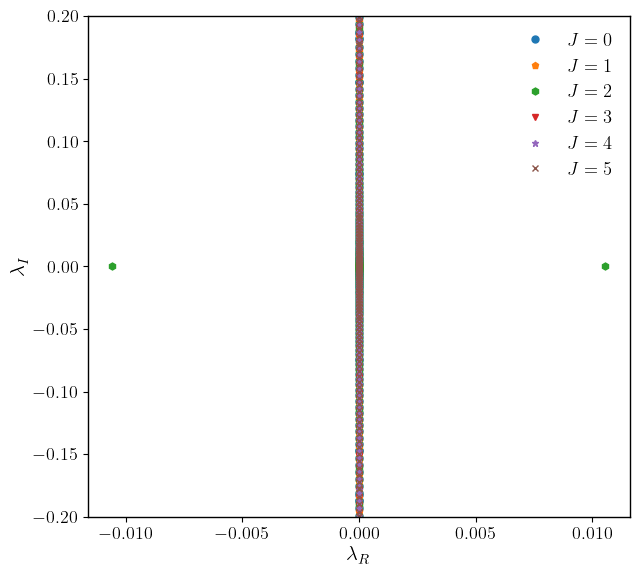

In [62]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran17):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

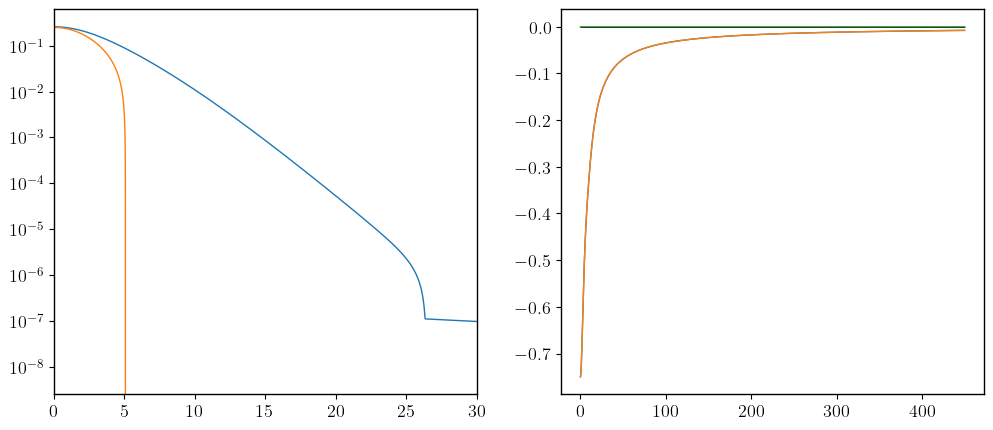

In [63]:
# perf 18

datE = []
datFunc = [[], []]
for s0dat in datasS0[18]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3*rMax/4) #* 2

Jval = [0, 1, 2, 3, 4 ,5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn18, dataExtran18 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [64]:
for ind, [Jval, data] in enumerate(dataExtran18):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00747865+0.20005501j  0.00747865+0.20005501j  0.00747865-0.20005501j
 -0.00747865-0.20005501j]
Jval = 1
[]
Jval = 2
[ 0.01202216-4.61821318e-16j -0.01202216-4.64888947e-16j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

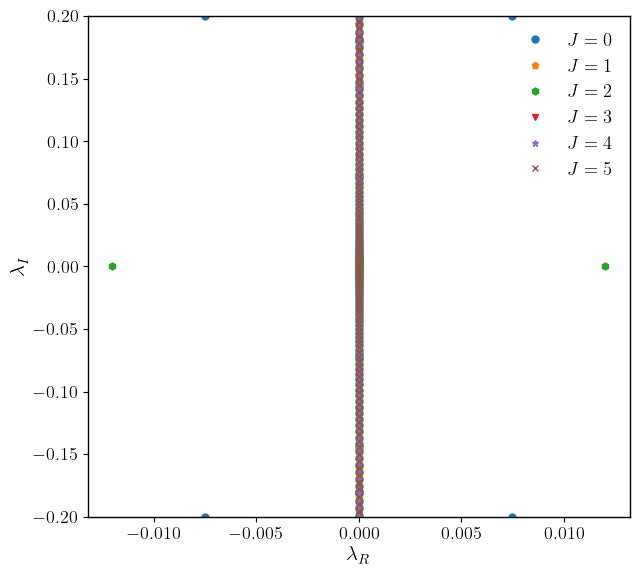

In [65]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran18):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

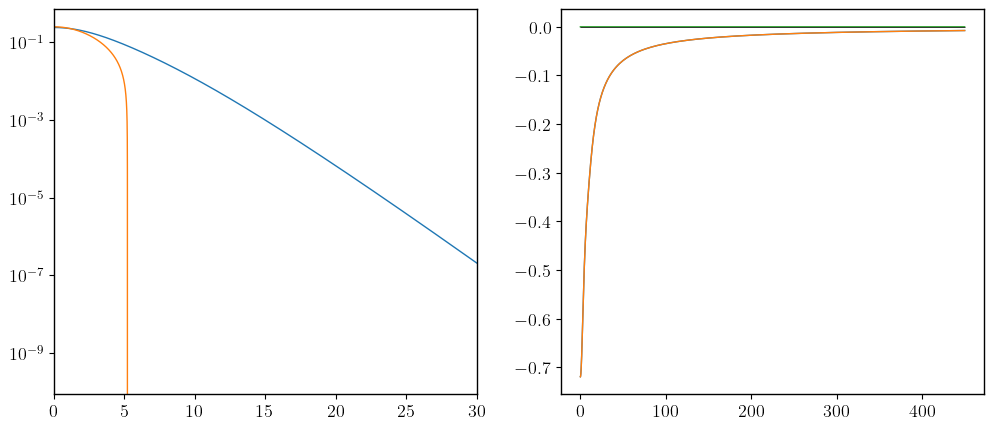

In [66]:
# perf 19

datE = []
datFunc = [[], []]
for s0dat in datasS0[19]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3 * rMax / 4) #* 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn19, dataExtran19 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [67]:
for ind, [Jval, data] in enumerate(dataExtran19):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.00897602+0.19375388j  0.00897602+0.19375388j  0.00897602-0.19375388j
 -0.00897602-0.19375388j]
Jval = 1
[]
Jval = 2
[-0.01478387+7.59616767e-16j  0.01478387+3.68894711e-16j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

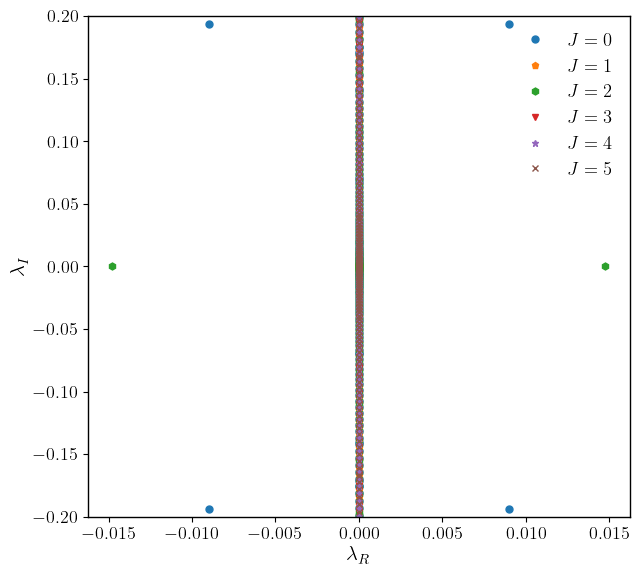

In [68]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran19):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

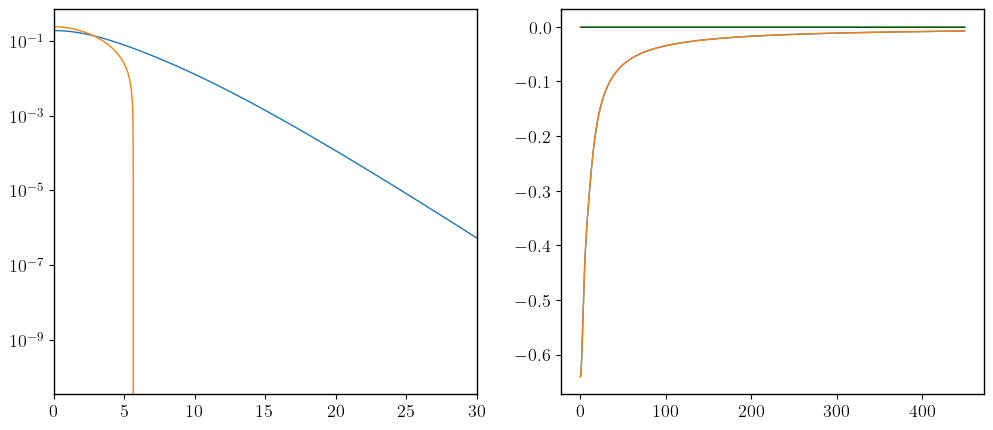

In [69]:
# perf 20

datE = []
datFunc = [[], []]
for s0dat in datasS0[20]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200 * (nodos + 1) + 50
Nptos = int(3*rMax/4) # * 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn20, dataExtran20 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [70]:
for ind, [Jval, data] in enumerate(dataExtran20):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.01200552+0.17532734j  0.01200552+0.17532734j  0.01200552-0.17532734j
 -0.01200552-0.17532734j]
Jval = 1
[]
Jval = 2
[ 0.01854236+8.45457053e-17j -0.01854236-3.30825507e-17j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

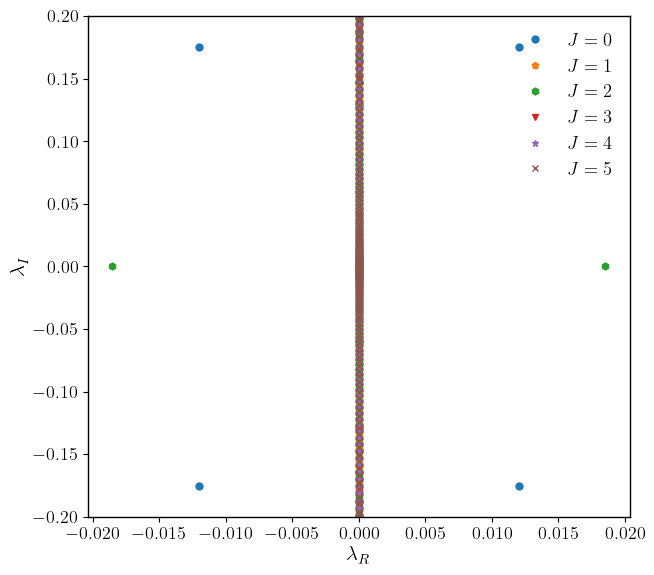

In [71]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran20):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

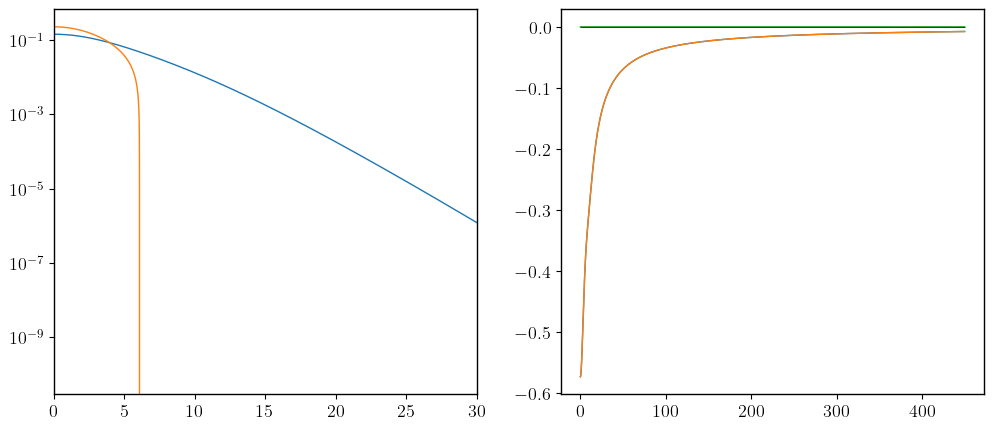

In [72]:
# perf 21

datE = []
datFunc = [[], []]
for s0dat in datasS0[21]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) #* 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn21, dataExtran21 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [73]:
for ind, [Jval, data] in enumerate(dataExtran21):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[ 0.01467831-0.1576287j -0.01467831-0.1576287j -0.01467831+0.1576287j
  0.01467831+0.1576287j]
Jval = 1
[]
Jval = 2
[-0.02017129+1.30104261e-16j  0.02017129+1.37910516e-16j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

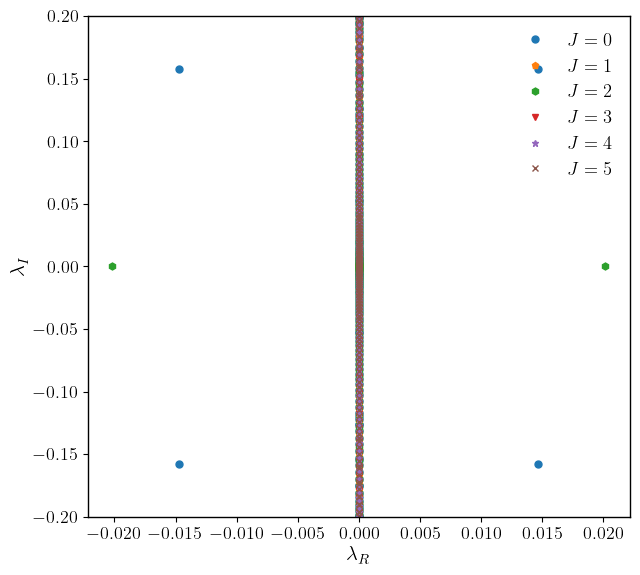

In [74]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran21):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

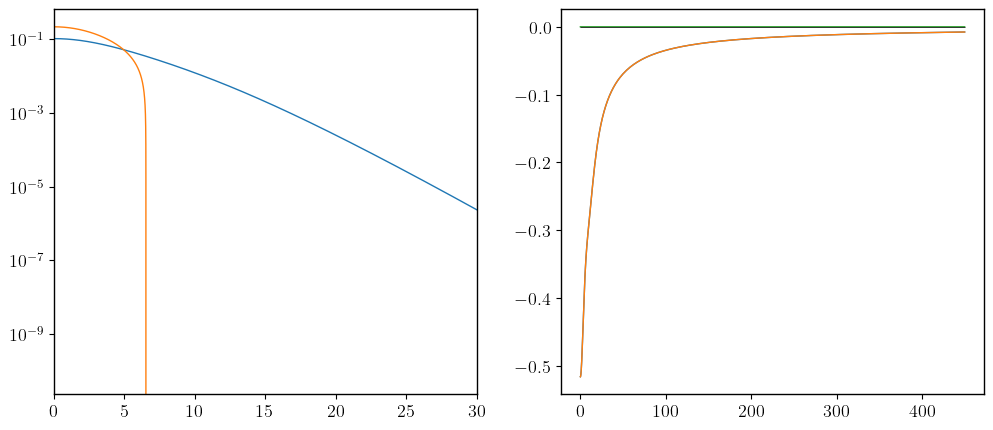

In [75]:
# perf 22

datE = []
datFunc = [[], []]
for s0dat in datasS0[22]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) #* 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn22, dataExtran22 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [76]:
for ind, [Jval, data] in enumerate(dataExtran22):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[ 0.01666316-0.14213253j -0.01666316-0.14213253j -0.01666316+0.14213253j
  0.01666316+0.14213253j]
Jval = 1
[]
Jval = 2
[ 0.02061891+5.29187344e-16j -0.02061891+7.13228053e-16j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

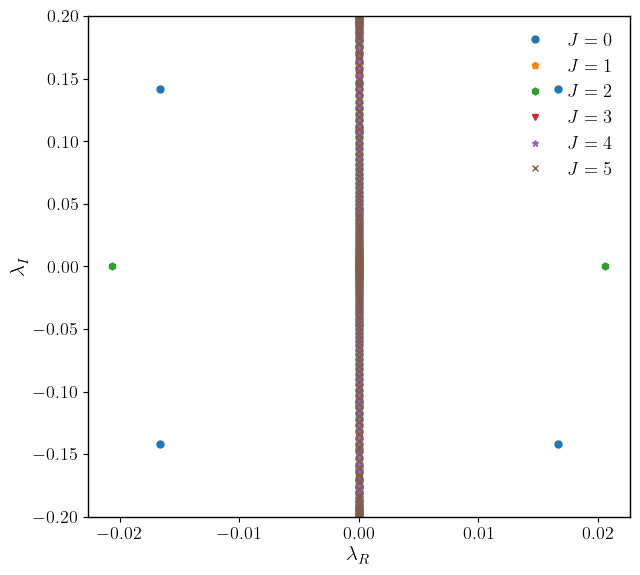

In [77]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran22):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

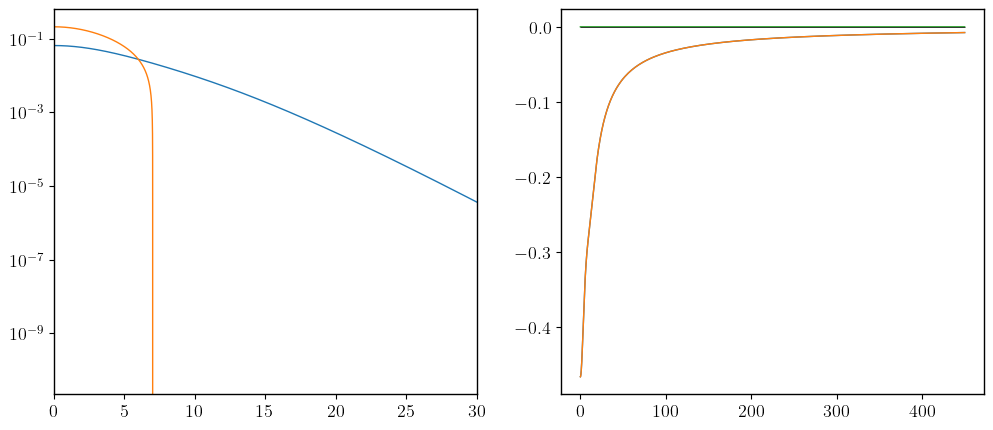

In [78]:
# perf 23

datE = []
datFunc = [[], []]
for s0dat in datasS0[23]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) #* 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn23, dataExtran23 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [79]:
for ind, [Jval, data] in enumerate(dataExtran23):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.01762+0.12838882j  0.01762+0.12838882j  0.01762-0.12838882j
 -0.01762-0.12838882j]
Jval = 1
[]
Jval = 2
[ 0.02043493+3.04715233e-16j -0.02043493-2.56839404e-16j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

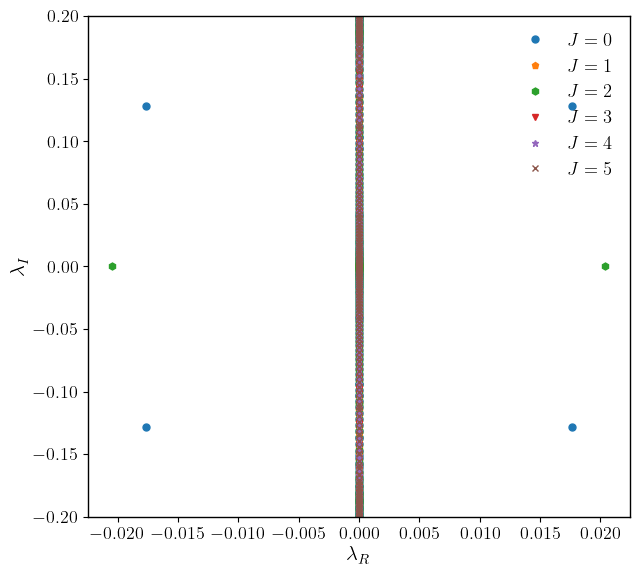

In [80]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran23):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

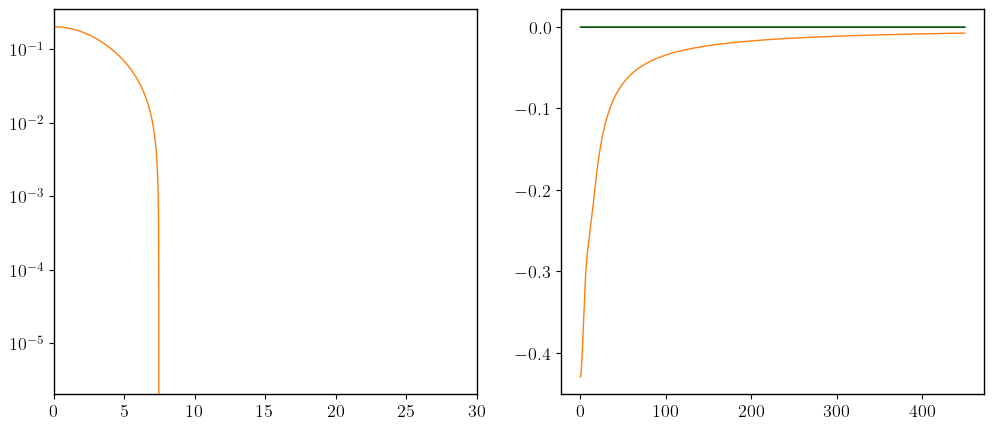

In [81]:
# perf 24

datE = []
datFunc = [[], []]
for s0dat in datasS0[24]:
    Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s0dat
    datFunc[0].append(interp1d(rDnew, sDnew))
    datFunc[1].append(interp1d(rDnew, uDnew))
    datE.append(Ei)

polariz = 'multifrequency'

nodos = 1
rMax = 200*(nodos+1) + 50
Nptos = int(3*rMax/4) #* 2

Jval = [0, 1, 2, 3, 4, 5]
lamV = [0, 0]
alp = 0.0

# Graphing
rad = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

label = ['x', 'y', 'z']
for i in range(3):
    ax[0].plot(rad, datFunc[0][i](rad), label=r'$\sigma_%s$'%label[i], lw=1)
    ax[1].plot(rad, datE[i] - datFunc[1][i](rad), label=r'$u_%s$'%label[i], lw=1)

ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaValn24, dataExtran24 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [82]:
for ind, [Jval, data] in enumerate(dataExtran24):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[ 0.0178312-0.1177467j -0.0178312-0.1177467j -0.0178312+0.1177467j
  0.0178312+0.1177467j]
Jval = 1
[]
Jval = 2
[-0.0200337+2.71277167e-15j  0.0200337+2.63448742e-15j]
Jval = 3
[]
Jval = 4
[]
Jval = 5
[]


Text(0, 0.5, '$\\lambda_I$')

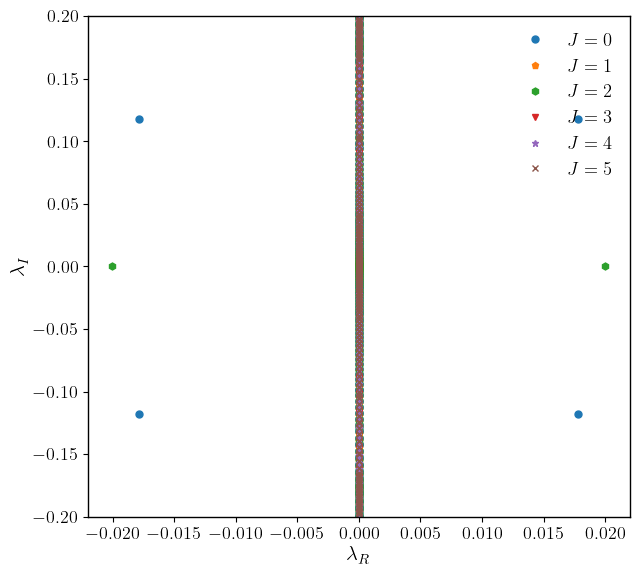

In [83]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e", "#e7ba05", "#a50979"]
mark = ['o', 'p', 'h', 'v', '*', 'x']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran24):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.05, 0.05)
ax.set_ylim(-.2, .2)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [84]:
# Eingevalues
data = [dataExtra, dataExtran1, dataExtran2, dataExtran3, dataExtran4, dataExtran5, dataExtran6,
        dataExtran7, dataExtran8, dataExtran9, dataExtran10, dataExtran11, dataExtran12, dataExtran13, dataExtran14,
        dataExtran15, dataExtran16, dataExtran17, dataExtran18, dataExtran19, dataExtran20, dataExtran21, dataExtran22, dataExtran23, dataExtran24]

In [85]:
temp = np.array(data, dtype="object")
# np.save("data_Mult", temp)

In [86]:
JModes = [[], [], [], [], [], []]
JVect = [[], [], [], [], [], []]
for dat in data:
    for ind, [Jval, data2] in enumerate(dat):
        rdis, eingVal, eigVect = data2
        # print('Jval = %d'%Jval)
        ind2 = np.abs(np.real(eingVal)) >= 1e-9 # filtrando los autovalores reales
        # print(eingVal[ind2])
        
        JModes[ind].append(eingVal[ind2])
        JVect[ind].append([rdis, eigVect[:, ind]])
        

In [87]:
temp = np.array(JModes, dtype="object")
np.save("data_JModes", temp)

temp = np.array(JVect, dtype="object")
np.save("data_JVect", temp)

In [88]:
# Plot

In [6]:
JModes = np.load("stability_free_case/Multifrequency/data_JModes.npy", allow_pickle=True)
JVect = np.load("stability_free_case/Multifrequency/data_JVect.npy", allow_pickle=True)
datosMasa = np.load("stability_free_case/Multifrequency/multif_masa_i.npy", allow_pickle=True)

In [7]:
totalM = np.sum(datosMasa, axis=1)
totalM

array([43.58339249, 43.41891587, 43.51553875, 43.52873646, 43.59503116,
       43.47851894, 43.50984041, 43.51666734, 43.55077639, 43.54283975,
       43.59971928, 43.58520772, 43.57480224, 43.58340018, 43.48867238,
       43.48366694, 43.59986544, 43.57092481, 43.47041079, 43.56816652,
       43.5249436 , 43.55939191, 43.56430151, 43.53230233, 43.56747673])

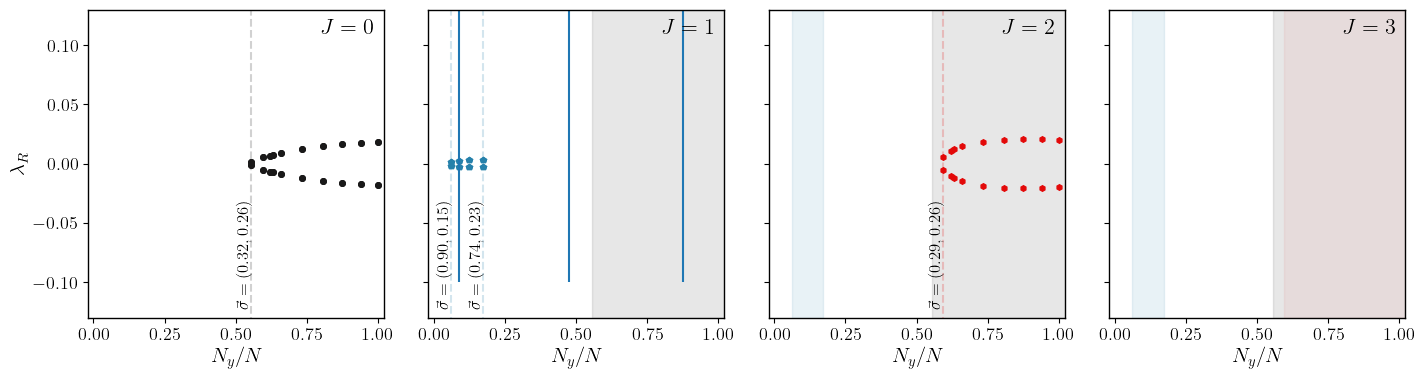

In [9]:
#col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 4.),
                       sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

for i in range(4):
    for j in range(len(totalM)):
        modos = JModes[i][j]
        ind2 = np.abs(np.real(modos)) >= 1e-6
        modos = modos[ind2]
        ax[i].plot([(datosMasa[j][1]/totalM[j])]*len(modos), np.real(modos), ls='', marker=mark[i], c=col[i], markersize='4')
        

for ind, axes in enumerate(ax):
    axes.text(x=0.8, y=0.11, s=r'$J=%d$'%ind)
    axes.set_xlim(-0.02, 1.02)
    axes.set_ylim(-0.13, .13)
    axes.set_xlabel(r'$N_y/N$')

ax[0].set_ylabel(r'$\lambda_R$')

jv = 15
xR = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax[0].text(x=xR-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=12, rotation=90)
ax[0].vlines(x=xR, ymin=-0.2, ymax=0.2, ls='--', color=col[0], alpha=0.2)

for i in range(1, 4):
    ax[i].axvspan(xmin=xR, xmax=1.4, color=col[0], alpha=0.1)

jv = 6
xR1 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax[1].text(x=xR1-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=12, rotation=90)
ax[1].vlines(x=xR1, ymin=-0.2, ymax=0.2, ls='--', color=col[1], alpha=0.2)

jv = 9
xR12 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax[1].text(x=xR12-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=12, rotation=90)
ax[1].vlines(x=xR12, ymin=-0.2, ymax=0.2, ls='--', color=col[1], alpha=0.2)

for i in range(2, 4):
    ax[i].axvspan(xmin=xR1, xmax=xR12, color=col[1], alpha=0.1)


jv = 16
xR2 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax[2].text(x=xR2-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=12, rotation=90)
ax[2].vlines(x=xR2, ymin=-0.2, ymax=0.2, ls='--', color=col[2], alpha=0.2)

for i in range(3, 4):
    ax[i].axvspan(xmin=xR2, xmax=1.2, color=col[2], alpha=0.05)

ax[1].vlines(x=0.08771356026486721, ymin=-0.1, ymax=0.2)
ax[1].vlines(x=0.8744055494643483, ymin=-0.1, ymax=0.2)
ax[1].vlines(x=0.4761740769163452, ymin=-0.1, ymax=0.2)


16 0.5943398196528641 [ 0.00525841-6.36273889e-16j -0.00525841-8.54303994e-16j]
17 0.6196125095333257 [ 0.01057111-4.49968997e-16j -0.01057111+1.11734588e-15j]
18 0.6312358272128707 [ 0.01202216-4.61821318e-16j -0.01202216-4.64888947e-16j]
19 0.6599357910218417 [-0.01478387+7.59616767e-16j  0.01478387+3.68894711e-16j]
20 0.7326836584086698 [ 0.01854236+8.45457053e-17j -0.01854236-3.30825507e-17j]
21 0.8057456597939034 [-0.02017129+1.30104261e-16j  0.02017129+1.37910516e-16j]
22 0.8744055494642021 [ 0.02061891+5.29187344e-16j -0.02061891+7.13228053e-16j]
23 0.941000835400686 [ 0.02043493+3.04715233e-16j -0.02043493-2.56839404e-16j]
24 1.0 [-0.0200337+2.71277167e-15j  0.0200337+2.63448742e-15j]


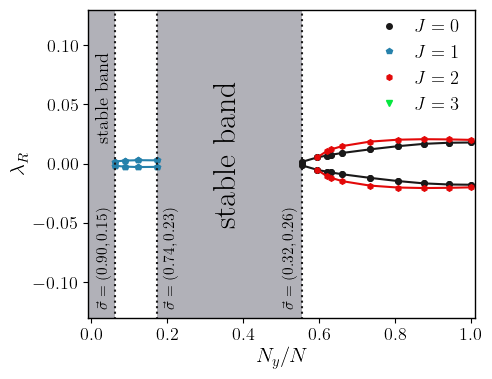

In [16]:
#col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4.),
                       sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

for i in range(4):
    tempP, tempN = [], []
    for j in range(len(totalM)):
        modos = JModes[i][j]
        ind2 = np.abs(np.real(modos)) >= 1e-6
        modos = modos[ind2]
        if len(modos) == 0:
            continue
        if i == 2:
            print(j, datosMasa[j][1]/totalM[j], modos)
        ax.plot([(datosMasa[j][1]/totalM[j])]*len(modos), np.real(modos), ls='', marker=mark[i], c=col[i], markersize='4')
        
        for mod in np.real(modos):
            if mod > 0:
                tempP.append([(datosMasa[j][1]/totalM[j]), mod])
            elif mod < 0:
                tempN.append([(datosMasa[j][1]/totalM[j]), mod])

    tempP = np.array(tempP, dtype="object")
    tempN = np.array(tempN, dtype="object")
    if tempP.size != 0 or tempN.size != 0:
        ax.plot(tempP[:, 0], tempP[:,1], ls='-', c=col[i])
        ax.plot(tempN[:, 0], tempN[:,1], ls='-', c=col[i])
    ax.plot([], [], ls='', marker=mark[i], c=col[i], markersize='4', label=r'$J=%d$'%i)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.13, .13)
    ax.set_xlabel(r'$N_y/N$')    
ax.set_ylabel(r'$\lambda_R$')

jv = 15
xR = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
# ax.axvspan(xmin=xR, xmax=1.4, color=col[0], alpha=0.1)

jv = 6
xR1 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR1-0.05, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR1, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
# ax.vlines(x=xR1, ymin=-0.2, ymax=0.2, ls='--', color=col[1], lw=1, alpha=1, zorder=10)

jv = 9
xR12 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR12 + 0.015, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR12, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])

# ax.vlines(x=xR12, ymin=-0.2, ymax=0.2, ls='--', color=col[1], alpha=0.2)
# ax.axvspan(xmin=xR1, xmax=xR12, color=col[1], alpha=0.1)


jv = 16
xR2 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
# ax.text(x=xR2-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
# ax.vlines(x=xR2, ymin=-0.2, ymax=0.2, ls='--', color=col[2], alpha=0.2)
# ax.axvspan(xmin=xR2, xmax=1.2, color=col[2], alpha=0.05)


ax.axvspan(-0.1, xR1, facecolor='#656473', alpha=0.5)
ax.axvspan(xR12, xR, facecolor='#656473', alpha=0.5)


ax.text(0.32, -0.05, s=r'stable band', rotation='vertical', fontsize='x-large')#, fontsize='small'
ax.text(0.011, 0.02, s=r'stable band', rotation='vertical', fontsize='small')
ax.legend(frameon=False, fontsize='small', loc=(0.71, 0.64), ncol=1, columnspacing=0.2, handletextpad=0.4)

In [105]:
fig.savefig('multifrequency.pdf', format='pdf', #metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )

16 0.5943398196528641 [ 0.00525841-6.36273889e-16j -0.00525841-8.54303994e-16j]
17 0.6196125095333257 [ 0.01057111-4.49968997e-16j -0.01057111+1.11734588e-15j]
18 0.6312358272128707 [ 0.01202216-4.61821318e-16j -0.01202216-4.64888947e-16j]
19 0.6599357910218417 [-0.01478387+7.59616767e-16j  0.01478387+3.68894711e-16j]
20 0.7326836584086698 [ 0.01854236+8.45457053e-17j -0.01854236-3.30825507e-17j]
21 0.8057456597939034 [-0.02017129+1.30104261e-16j  0.02017129+1.37910516e-16j]
22 0.8744055494642021 [ 0.02061891+5.29187344e-16j -0.02061891+7.13228053e-16j]
23 0.941000835400686 [ 0.02043493+3.04715233e-16j -0.02043493-2.56839404e-16j]
24 1.0 [-0.0200337+2.71277167e-15j  0.0200337+2.63448742e-15j]


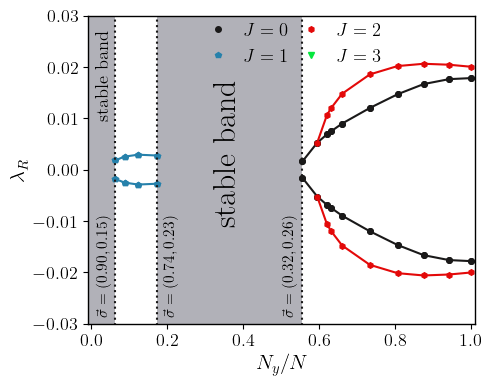

In [19]:
#col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4.),
                       sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

for i in range(4):
    tempP, tempN = [], []
    for j in range(len(totalM)):
        modos = JModes[i][j]
        ind2 = np.abs(np.real(modos)) >= 1e-6
        modos = modos[ind2]
        if len(modos) == 0:
            continue
        if i == 2:
            print(j, datosMasa[j][1]/totalM[j], modos)
        ax.plot([(datosMasa[j][1]/totalM[j])]*len(modos), np.real(modos), ls='', marker=mark[i], c=col[i], markersize='4')
        
        for mod in np.real(modos):
            if mod > 0:
                tempP.append([(datosMasa[j][1]/totalM[j]), mod])
            elif mod < 0:
                tempN.append([(datosMasa[j][1]/totalM[j]), mod])

    tempP = np.array(tempP, dtype="object")
    tempN = np.array(tempN, dtype="object")
    if tempP.size != 0 or tempN.size != 0:
        ax.plot(tempP[:, 0], tempP[:,1], ls='-', c=col[i])
        ax.plot(tempN[:, 0], tempN[:,1], ls='-', c=col[i])
    ax.plot([], [], ls='', marker=mark[i], c=col[i], markersize='4', label=r'$J=%d$'%i)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.03, .03)
    ax.set_xlabel(r'$N_y/N$')    
ax.set_ylabel(r'$\lambda_R$')

jv = 15
xR = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR-0.055, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
# ax.axvspan(xmin=xR, xmax=1.4, color=col[0], alpha=0.1)

jv = 6
xR1 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR1-0.05, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR1, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
# ax.vlines(x=xR1, ymin=-0.2, ymax=0.2, ls='--', color=col[1], lw=1, alpha=1, zorder=10)

jv = 9
xR12 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR12 + 0.015, y=-0.028, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR12, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])

# ax.vlines(x=xR12, ymin=-0.2, ymax=0.2, ls='--', color=col[1], alpha=0.2)
# ax.axvspan(xmin=xR1, xmax=xR12, color=col[1], alpha=0.1)


#jv = 16
#xR2 = (datosMasa[jv][1]/totalM[jv])
#_, _, sDnewx, _, _, _ = datasS0[jv][0]
#_, _, sDnewy, _, _, _ = datasS0[jv][1]
# ax.text(x=xR2-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
# ax.vlines(x=xR2, ymin=-0.2, ymax=0.2, ls='--', color=col[2], alpha=0.2)
# ax.axvspan(xmin=xR2, xmax=1.2, color=col[2], alpha=0.05)


ax.axvspan(-0.1, xR1, facecolor='#656473', alpha=0.5)
ax.axvspan(xR12, xR, facecolor='#656473', alpha=0.5)


ax.text(0.32, -0.01, s=r'stable band', rotation='vertical', fontsize='x-large')#, fontsize='small'
ax.text(0.011, 0.01, s=r'stable band', rotation='vertical', fontsize='small')
ax.legend(frameon=False, fontsize='small', loc=(0.27, 0.815), ncol=2, columnspacing=0.2, handletextpad=0.4)

In [20]:
fig.savefig('multifrequency.pdf', format='pdf', #metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )

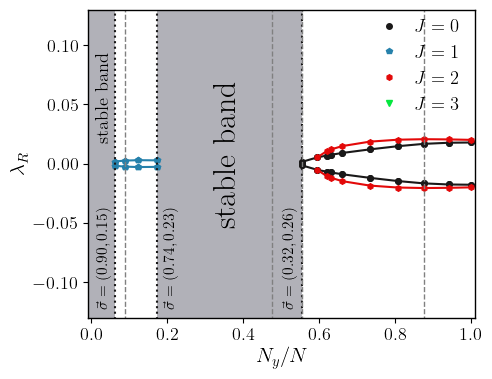

In [13]:

#col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4.),
                       sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

for i in range(4):
    tempP, tempN = [], []
    for j in range(len(totalM)):
        modos = JModes[i][j]
        ind2 = np.abs(np.real(modos)) >= 1e-6
        modos = modos[ind2]
        if len(modos) == 0:
            continue
        ax.plot([(datosMasa[j][1]/totalM[j])]*len(modos), np.real(modos), ls='', marker=mark[i], c=col[i], markersize='4')
        
        for mod in np.real(modos):
            if mod > 0:
                tempP.append([(datosMasa[j][1]/totalM[j]), mod])
            elif mod < 0:
                tempN.append([(datosMasa[j][1]/totalM[j]), mod])

    tempP = np.array(tempP, dtype="object")
    tempN = np.array(tempN, dtype="object")
    if tempP.size != 0 or tempN.size != 0:
        ax.plot(tempP[:, 0], tempP[:,1], ls='-', c=col[i])
        ax.plot(tempN[:, 0], tempN[:,1], ls='-', c=col[i])
    ax.plot([], [], ls='', marker=mark[i], c=col[i], markersize='4', label=r'$J=%d$'%i)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.13, .13)
    ax.set_xlabel(r'$N_y/N$')    
ax.set_ylabel(r'$\lambda_R$')

jv = 15
xR = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
# ax.axvspan(xmin=xR, xmax=1.4, color=col[0], alpha=0.1)

jv = 6
xR1 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR1-0.05, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR1, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
# ax.vlines(x=xR1, ymin=-0.2, ymax=0.2, ls='--', color=col[1], lw=1, alpha=1, zorder=10)

jv = 9
xR12 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
ax.text(x=xR12 + 0.015, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
ax.vlines(x=xR12, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])

# ax.vlines(x=xR12, ymin=-0.2, ymax=0.2, ls='--', color=col[1], alpha=0.2)
# ax.axvspan(xmin=xR1, xmax=xR12, color=col[1], alpha=0.1)


jv = 16
xR2 = (datosMasa[jv][1]/totalM[jv])
_, _, sDnewx, _, _, _ = datasS0[jv][0]
_, _, sDnewy, _, _, _ = datasS0[jv][1]
# ax.text(x=xR2-0.055, y=-0.12, s=r'$\vec{\sigma}=(%3.2f, %3.2f)$'%(sDnewx[0], sDnewy[0]), fontsize=11, rotation=90)
# ax.vlines(x=xR2, ymin=-0.2, ymax=0.2, ls='--', color=col[2], alpha=0.2)
# ax.axvspan(xmin=xR2, xmax=1.2, color=col[2], alpha=0.05)


ax.axvspan(-0.1, xR1, facecolor='#656473', alpha=0.5)
ax.axvspan(xR12, xR, facecolor='#656473', alpha=0.5)


ax.text(0.32, -0.05, s=r'stable band', rotation='vertical', fontsize='x-large')#, fontsize='small'
ax.text(0.011, 0.02, s=r'stable band', rotation='vertical', fontsize='small')
ax.legend(frameon=False, fontsize='small', loc=(0.71, 0.64), ncol=1, columnspacing=0.2, handletextpad=0.4)


ax.vlines(x=0.08771356026486721, ymin=-0.2, ymax=0.2, lw=1, ls='--', color='gray')
ax.vlines(x=0.8744055494643483, ymin=-0.2, ymax=0.2, lw=1, ls='--', color='gray')
ax.vlines(x=0.5552801506020925, ymin=-0.2, ymax=0.2, lw=1, ls='--', color='gray')
ax.vlines(x=0.4761740769163452, ymin=-0.2, ymax=0.2, lw=1, ls='--', color='gray')


In [14]:
fig.savefig('multifrequency_simulation.pdf', format='pdf', #metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )